## 1. What this notebook computes

The 16 components of the author's spinor field are acted on by two groups of
$16 \times 16$ matrices: **Pin(4,4)**, made of products of gamma matrices, and its
subgroup **Spin(4,4)**, made of products of an *even* number of them. The Revision
record states, and this notebook verifies with its own exact computation:

1. the $2^8 = 256$ products of different gammas are linearly independent, so they
   span all $16 \times 16$ matrices;
2. only the multiples of the identity commute with all eight gammas (the
   *commutant* has dimension 1): the 16 components form an **irreducible**
   representation of Pin(4,4);
3. the matrices that commute with all 28 generators $S^{ab}$ of Spin(4,4) form a
   space of dimension 2, spanned by the two chiral projectors $P_-$ and $P_+$:
   under Spin(4,4) the 16 components split into two halves of 8;
4. each half is irreducible (commutant dimension 1), and the two halves are
   **inequivalent**: the only matrix that carries one half into the other while
   respecting Spin(4,4) is zero.

The method is the same for every statement: a matrix equation such as
$X\gamma^a = \gamma^a X$ for an unknown matrix $X$ is a system of *linear
equations* for the 256 entries of $X$, and the number of independent solutions is
256 minus the *rank* of the system. Every check that repeats a recorded check
prints the record file and the check name. Five teaching plots show the counts and
the dimensions; a negative control shows what the computation would give if the
two halves were equivalent.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 05b (Commutants: Pin(4,4) acts irreducibly, Spin(4,4) splits into two
inequivalent halves) is the file `Revision/textbook/notebooks/05b_commutants.ipynb` of
the repository Dirac_claude. It turns the matrix equations X M = M X into systems of
linear equations for the 256 entries of an unknown 16 by 16 matrix X, solves them
exactly, and so computes: the rank of the 256 Clifford products, the commutant of the
eight gammas (dimension 1: the 16 components carry an irreducible representation of
Pin(4,4)), the commutant of the 28 generators S^ab (dimension 2, spanned by the chiral
projectors), the commutants of the two halves (1 and 1) and the intertwiners between them
(0 and 0: inequivalent halves), with a negative control that shows what equivalent halves
would give. Five teaching plots show the counts, the eigenvalues of the equation systems
and the dimensions. It needs a computer with Windows 11, macOS or Linux, an internet
connection for the installation, the program Git, and Python 3.12 or newer (the notebooks
were built with Python 3.14.5) with these packages at exactly these versions: numpy
2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4,
nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself imports numpy,
sympy and matplotlib; the other packages run Jupyter, the program that shows and runs
notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (about 130 MB; the folder then takes about 400
MB of disk space) into the folder Dirac_claude inside your home folder, create a private
Python environment in the folder dirac-book-env inside your home folder (a private
environment is a folder with its own copy of Python and of the packages, so that nothing
else on your computer is changed), activate it (from then on the commands `python` and
`jupyter` typed in this terminal are those of the environment, and the prompt starts with
(dirac-book-env)), and install the packages at the pinned versions (this downloads about
90 MB and takes a few minutes; the environment takes about 400 MB of disk space). If you
have done this step before, for this or for another notebook, skip it and go to Step 4;
to get the newest version of the repository, run `git pull` in the repository folder
after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 05b_commutants.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 20 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 05b_commutants.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
05b_commutants.ipynb` (in the same folder, without running the cells again) to read the
printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/05b.captions.json`
- `Revision/textbook/figures/05b_1_clifford_products.png`
- `Revision/textbook/figures/05b_2_system_eigenvalues.png`
- `Revision/textbook/figures/05b_3_commutant_halving.png`
- `Revision/textbook/figures/05b_4_spin_commutant.png`
- `Revision/textbook/figures/05b_5_dimensions.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS the five figure files of notebook 05b exist
    ALL 16 CHECKS PASSED (notebook 05b)

and the notebook must show 5 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/05b_commutants.ipynb` inside the folder Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "FileNotFoundError" naming `Revision/algebra/gammas.json`: the notebook was opened
  outside the repository, or the repository is incomplete; clone the repository again and
  open the notebook from its folder `Revision/textbook/notebooks`.
- the cells of sections 10 and 11 take much longer than a few seconds: they solve 7168
  linear equations exactly; on a slow computer they may take a minute. Wait until the
  star in the brackets left of the cell turns into a number.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 05b (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 05b (Commutants: Pin(4,4) acts irreducibly, Spin(4,4) splits into two
# inequivalent halves) is the file Revision/textbook/notebooks/05b_commutants.ipynb of
# the repository Dirac_claude. It turns the matrix equations X M = M X into systems of
# linear equations for the 256 entries of an unknown 16 by 16 matrix X, solves them
# exactly, and so computes: the rank of the 256 Clifford products, the commutant of the
# eight gammas (dimension 1: the 16 components carry an irreducible representation of
# Pin(4,4)), the commutant of the 28 generators S^ab (dimension 2, spanned by the chiral
# projectors), the commutants of the two halves (1 and 1) and the intertwiners between
# them (0 and 0: inequivalent halves), with a negative control that shows what equivalent
# halves would give. Five teaching plots show the counts, the eigenvalues of the equation
# systems and the dimensions. It needs a computer with Windows 11, macOS or Linux, an
# internet connection for the installation, the program Git, and Python 3.12 or newer
# (the notebooks were built with Python 3.14.5) with these packages at exactly these
# versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab
# 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The
# notebook itself imports numpy, sympy and matplotlib; the other packages run Jupyter,
# the program that shows and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (about 130 MB; the folder then takes about
# 400 MB of disk space) into the folder Dirac_claude inside your home folder, create a
# private Python environment in the folder dirac-book-env inside your home folder (a
# private environment is a folder with its own copy of Python and of the packages, so
# that nothing else on your computer is changed), activate it (from then on the commands
# python and jupyter typed in this terminal are those of the environment, and the prompt
# starts with (dirac-book-env)), and install the packages at the pinned versions (this
# downloads about 90 MB and takes a few minutes; the environment takes about 400 MB of
# disk space). If you have done this step before, for this or for another notebook, skip
# it and go to Step 4; to get the newest version of the repository, run git pull in the
# repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 05b_commutants.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 20
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 05b_commutants.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 05b_commutants.ipynb (in the same folder, without running the cells again) to read the
# printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/05b.captions.json
# - Revision/textbook/figures/05b_1_clifford_products.png
# - Revision/textbook/figures/05b_2_system_eigenvalues.png
# - Revision/textbook/figures/05b_3_commutant_halving.png
# - Revision/textbook/figures/05b_4_spin_commutant.png
# - Revision/textbook/figures/05b_5_dimensions.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS the five figure files of notebook 05b exist
#     ALL 16 CHECKS PASSED (notebook 05b)
#
# and the notebook must show 5 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/05b_commutants.ipynb inside the folder Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "FileNotFoundError" naming Revision/algebra/gammas.json: the notebook was opened
#   outside the repository, or the repository is incomplete; clone the repository again
#   and open the notebook from its folder Revision/textbook/notebooks.
# - the cells of sections 10 and 11 take much longer than a few seconds: they solve 7168
#   linear equations exactly; on a slow computer they may take a minute. Wait until the
#   star in the brackets left of the cell turns into a number.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "05b"  # this notebook: chapter 05, example b


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 05b complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Linear equation, system**: an equation of the form $c_1 y_1 + c_2 y_2 + \dots
  + c_n y_n = 0$ for unknown numbers $y_1, \dots, y_n$ with given coefficients
  $c_j$. A *system* is a list of such equations; its coefficients form the
  **coefficient matrix** $A$ (one row per equation), and the system reads
  $Ay = 0$.
- **Solution space, dimension**: the set of all solutions $y$ of $Ay = 0$. Sums
  and multiples of solutions are solutions. Its **dimension** is the number of
  solutions needed so that every solution is a combination of them (a
  **basis**).
- **Rank**: the number of independent rows of $A$ (rows that are not combinations
  of other rows). For $n$ unknowns: dimension of the solution space $= n -
  \text{rank}$.
- **Exact arithmetic**: computing with fractions, never rounding. The package
  sympy does this (`DomainMatrix` over `QQ`, the rational numbers).
- **Linearly independent matrices**: no one of them is a combination of the
  others. Writing each $16 \times 16$ matrix as one row of 256 numbers, $N$ matrices
  are independent when these $N$ rows have rank $N$.
- **Span**: all combinations of a list of matrices.
- **Clifford product**: a product $\gamma^{a_1}\gamma^{a_2}\cdots\gamma^{a_k}$ of
  $k$ *different* gammas, taken in the order $x1, \dots, x8$; $k$ is its
  **degree**; it is **even** or **odd** with $k$. The degree-0 product is $1$.
- **Group**: a set of invertible matrices that contains the products and the
  inverses of its members.
- **Representation, invariant subspace, irreducible**: a group of $16 \times 16$
  matrices *represents* the group on columns of 16 numbers. A set of columns that
  every group matrix maps into itself is *invariant*. The representation is
  **irreducible** when the only invariant subspaces are $\{0\}$ and everything.
- **Commutant**: all matrices $X$ that commute with every matrix of a list.
- **Intertwiner**: a matrix $X$ with $X M_k = N_k X$ for two lists of matrices
  $M_k$, $N_k$ (it carries the first representation into the second).
  **Equivalent** representations have an invertible intertwiner.
- **Schur's lemma** (used here, proved in the text): when the matrices of a
  representation span all matrices, the representation is irreducible and its
  commutant is the multiples of 1; an intertwiner between two irreducible
  representations is zero or invertible.
- **Generators** $S^{ab} = \tfrac14[\gamma^a, \gamma^b] = \tfrac14(\gamma^a\gamma^b
  - \gamma^b\gamma^a)$: the 28 matrices ($a < b$) from which every element of the
  part of Spin(4,4) connected to 1 is built as a product of exponentials
  $\exp(\theta S^{ab})$.
- **Chiral halves**: the components 1 to 8 (chirality $\Gamma = -1$) and 9 to 16
  ($\Gamma = +1$); $P_- = \mathrm{diag}(1_8, 0)$ and $P_+ = \mathrm{diag}(0, 1_8)$.
- **Kronecker product** `np.kron(L, R)`: the big matrix whose block in block row
  $r$ and block column $k$ is $L_{rk}$ times the whole matrix $R$.

## 4. The physical and mathematical situation

**From a matrix equation to linear equations.** Let $X$ be an unknown $n \times m$
matrix, $L$ a known $n \times n$ and $R$ a known $m \times m$ matrix, and consider
$LX - XR = 0$. List the $nm$ entries of $X$ row by row: $X_{11}, X_{12}, \dots,
X_{1m}, X_{21}, \dots$. The entry $(r, c)$ of the equation is

$$(LX)_{rc} - (XR)_{rc} = \sum_k L_{rk} X_{kc} - \sum_k X_{rk} R_{kc} = 0 .$$

In the first sum the unknown $X_{kc}$ has the coefficient $L_{rk}$; in the second
the unknown $X_{rk}$ has the coefficient $R_{kc}$. Collected over all $(r, c)$,
these coefficients form the matrix $\mathrm{kron}(L, 1_m) - \mathrm{kron}(1_n,
R^T)$, with one row per equation and one column per unknown. For a list of pairs
$(L_j, R_j)$ the coefficient matrices are stacked on top of each other. For the
commutant of the eight gammas: $n = m = 16$, $L_j = R_j = \gamma^{a}$, so
$8 \times 256 = 2048$ equations for 256 unknowns.

**How the two computations prove irreducibility.** Every element of Pin(4,4) is a
product of matrices $\gamma(u) = \sum_a u_a \gamma^a$, so it is a combination of
Clifford products; conversely every Clifford product is, up to a sign, an element
of Pin(4,4) (each $\gamma^a$ is one). So the span of Pin(4,4) is the span of the 256
Clifford products. *First computation*: if they span all $16 \times 16$ matrices,
then every invariant subspace is $\{0\}$ or everything (a subspace kept by every
matrix is $\{0\}$ or everything), and only the multiples of 1 commute with them
(Schur's lemma in its span form). *Second computation*: the commutant of the eight
gammas, solved directly; it confirms the second statement independently. For
Spin(4,4) the even products play the same role: if they span exactly the
block-diagonal matrices $\mathrm{diag}(X, Y)$, each half is irreducible and the two
halves are inequivalent (an intertwiner $T$ with $TX = YT$ for all $X$, $Y$ must
vanish: take $X = 1_8$, $Y = 0$). The commutant of the 28 generators $S^{ab}$, which
build the part of Spin(4,4) connected to 1, and the intertwiners between the two
halves are then computed directly, in the form in which the Revision record states
them.

**Two halves, equivalent or not.** If the 16 components split into two invariant
halves of 8 and each half is irreducible, the commutant has dimension 2 when the
halves are inequivalent ($X = p P_- + q P_+$) and dimension 4 when they are
equivalent (then a matrix that carries one half onto the other also commutes).
The notebook computes both the real case and an artificial *control* with two
equal halves.

**A second engine.** For a coefficient matrix $A$ the matrix $N = A^T A$ is
symmetric, and $Ny = 0$ exactly when $Ay = 0$: if $Ny = 0$, then
$0 = y^T N y = (Ay)^T(Ay) = |Ay|^2$, the sum of the squares of the entries of
$Ay$, so $Ay = 0$; the converse is clear. Hence the dimension of the solution space
equals the number of zero eigenvalues of $N$, which numpy computes in
floating-point numbers, independently of sympy.

## 5. The gammas and the recorded checks

The next cell reads the gammas from the record `Revision/algebra/gammas.json` (exact
whole numbers), reads the two Revision reports, and defines the helpers
`recorded(key, name)` (true when the report `key`, "python" or "wolfram", holds the
check `name` with the verdict pass), `detail(key, name)` (the detail text of that
check), `record_of(key, name)` (the text printed after "reproduces") and
`check_reproduces(condition, name, record)`, the helper `check` for a check that
reproduces a Revision record: it lets `check` print the PASS line and the line
"reproduces ..." into a text buffer (`contextlib.redirect_stdout`) and sends both
lines with one `sys.stdout.write`, because Jupyter delivers printed text in pieces
and one piece keeps the two lines together for the tools that read the notebook.
Then it checks the Clifford relation, on which everything below rests.

In [2]:
import contextlib  # lets a block of code print into a text buffer
import io  # the text buffer io.StringIO
import sys  # sys.stdout: the channel through which the notebook prints

import numpy as np  # arrays of numbers, matrices and linear algebra

fixture = json.loads(repository_file("Revision/algebra/gammas.json")
                     .read_text(encoding="utf-8"))
COORDS = fixture["coordinates"]  # "x1", ..., "x8"
ETA = dict(zip(COORDS, fixture["eta"]))  # +1 space-like, -1 time-like
gamma = {x: np.array(m, dtype=np.int64) for x, m in zip(COORDS, fixture["gamma"])}
I16 = np.eye(16, dtype=np.int64)  # the identity matrix 1

REPORT_FILES = {"python": "Revision/algebra/reports/python-algebra.json",
                "wolfram": "Revision/algebra/reports/wolfram-algebra.json"}
VERDICTS = {}  # (report key, check name) -> (verdict in lower case, detail text)
for key, path in REPORT_FILES.items():
    report_data = json.loads(repository_file(path).read_text(encoding="utf-8"))
    for entry in report_data["checks"]:
        VERDICTS[(key, entry["name"])] = (entry["verdict"].lower(), entry["detail"])


def recorded(key, name):
    """True when the report key records the check name with the verdict pass."""
    return VERDICTS[(key, name)][0] == "pass"


def detail(key, name):
    """The detail text of the recorded check."""
    return VERDICTS[(key, name)][1]


def record_of(key, name):
    """The text printed after "reproduces": the record file and the check name."""
    return f"{REPORT_FILES[key]}, check {name}"


def check_reproduces(condition, name, record):
    """check(condition, name, record=record), printed in one piece."""
    collected = io.StringIO()
    with contextlib.redirect_stdout(collected):  # print into the buffer
        check(condition, name, record=record)  # stops here if the check fails
    sys.stdout.write(collected.getvalue())  # the PASS and reproduces lines together


clifford_ok = all(
    np.array_equal(gamma[x] @ gamma[y] + gamma[y] @ gamma[x],
                   2 * ETA[x] * I16 if x == y else 0 * I16)
    for x in COORDS for y in COORDS)
check_reproduces(clifford_ok and recorded("python", "clifford_relation"),
                 "{gamma^a, gamma^b} = 2 eta^ab 1 for all 64 pairs",
                 record=record_of("python", "clifford_relation"))

PASS {gamma^a, gamma^b} = 2 eta^ab 1 for all 64 pairs
     reproduces Revision/algebra/reports/python-algebra.json, check clifford_relation


## 6. The tools: equation systems and their exact rank

The next cell defines three tools.

- `commutation_system(lefts, rights)` builds the coefficient matrix of the
  equations $L X - X R = 0$ for all pairs $(L, R)$ of the two lists, following
  section 4.
- `exact_rank(A)` computes the rank of a matrix of whole numbers exactly, with
  sympy's `DomainMatrix` over the rational numbers `QQ` (Gaussian elimination with
  fractions).
- `solution_basis(A, n, m)` returns a basis of the solutions as $n \times m$
  matrices (sympy's `nullspace`, also exact).

Then the cell tests the construction: for a random matrix $X$ of whole numbers
(from a random-number generator with the fixed seed 12345, so every run uses the
same numbers), the coefficient matrix applied to the entries of $X$ must give the
entries of $LX - XR$.

In [3]:
import sympy as sp  # exact algebra
from sympy.polys.matrices import DomainMatrix  # exact matrices over QQ


def commutation_system(lefts, rights):
    """Coefficient matrix of L X - X R = 0 for every pair (L, R); X is n x m with
    n = size of L and m = size of R; the unknowns are the entries of X row by row."""
    blocks = []
    for L, R in zip(lefts, rights):
        n, m = L.shape[0], R.shape[0]
        blocks.append(np.kron(L, np.eye(m, dtype=np.int64))
                      - np.kron(np.eye(n, dtype=np.int64), R.T))
    return np.vstack(blocks)  # the blocks stacked on top of each other


def exact_rank(A):
    """The rank of the whole-number matrix A, computed exactly."""
    return DomainMatrix.from_list(A.tolist(), sp.QQ).rank()


def solution_basis(A, n, m):
    """A basis of all solutions of A y = 0, each reshaped to an n x m matrix."""
    null = DomainMatrix.from_list(A.tolist(), sp.QQ).nullspace().to_Matrix()
    return [np.array(null.row(k).tolist()[0], dtype=float).reshape(n, m)
            for k in range(null.rows)]


rng = np.random.default_rng(12345)  # random numbers with a fixed seed
X = rng.integers(-5, 6, size=(16, 16))  # a random 16 x 16 matrix, entries -5..5
L, R = gamma["x1"], gamma["x4"]
A = commutation_system([L], [R])
say(f"one pair (L, R) gives {A.shape[0]} equations for {A.shape[1]} unknowns")
check(np.array_equal(A @ X.reshape(256), (L @ X - X @ R).reshape(256)),
      "the coefficient matrix applied to X row by row gives L X - X R")

one pair (L, R) gives 256 equations for 256 unknowns
PASS the coefficient matrix applied to X row by row gives L X - X R


**A warm-up with $2 \times 2$ matrices.** Which $2 \times 2$ matrices
$X = \begin{pmatrix} p & q \\ r & s \end{pmatrix}$ commute with
$M = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}$? By hand: $MX =
\begin{pmatrix} r & s \\ p & q \end{pmatrix}$ and $XM = \begin{pmatrix} q & p \\ s & r
\end{pmatrix}$, so $MX = XM$ means $r = q$ and $s = p$: the solutions are
$\begin{pmatrix} p & q \\ q & p \end{pmatrix}$, a space of dimension 2 (basis: the
identity and $M$ itself). The next cell gets the same answer from the tools: 4
equations, rank 2, dimension $4 - 2 = 2$.

In [4]:
M = np.array([[0, 1], [1, 0]], dtype=np.int64)
A_small = commutation_system([M], [M])  # 4 equations for the 4 entries p, q, r, s
rank_small = exact_rank(A_small)
basis_small = solution_basis(A_small, 2, 2)
say(f"coefficient matrix (rows = equations, columns = p, q, r, s):")
for row in A_small.tolist():
    say(f"    {row}")
say(f"rank {rank_small}; dimension of the solution space {4 - rank_small}")
for k, b in enumerate(basis_small, 1):
    say(f"basis solution {k}: rows {b.astype(int).tolist()}")
check(rank_small == 2 and len(basis_small) == 2,
      "warm-up: the 2 x 2 matrices commuting with M form a space of dimension 2")

coefficient matrix (rows = equations, columns = p, q, r, s):
    [0, -1, 1, 0]
    [-1, 0, 0, 1]
    [1, 0, 0, -1]
    [0, 1, -1, 0]
rank 2; dimension of the solution space 2
basis solution 1: rows [[0, 1], [1, 0]]
basis solution 2: rows [[1, 0], [0, 1]]
PASS warm-up: the 2 x 2 matrices commuting with M form a space of dimension 2


## 7. The 256 Clifford products span all 16 x 16 matrices

The next cell builds the Clifford products of every degree $k = 0, \dots, 8$ (for
each $k$, `itertools.combinations` lists the $\binom{8}{k}$ subsets of $k$
directions in the order $x1, \dots, x8$). It writes each product as one row of 256
numbers and computes exactly the rank of all 256 rows (must be 256: independent),
of the 128 even ones (must be 128), and the rank after adding the products degree
by degree. It also checks that every even product is block diagonal (it maps each
half into itself) and every odd product block off-diagonal (it exchanges the
halves).

In [5]:
import itertools  # subsets of a given size
from math import comb  # comb(8, k): the number of subsets of size k

products = {}  # degree k -> list of the Clifford products of degree k
for k in range(9):
    products[k] = []
    for subset in itertools.combinations(COORDS, k):
        p = I16
        for x in subset:
            p = p @ gamma[x]
        products[k].append(p)
rows_all = np.array([p.reshape(256) for k in range(9) for p in products[k]])
rows_even = np.array([p.reshape(256) for k in (0, 2, 4, 6, 8) for p in products[k]])
rank_all, rank_even = exact_rank(rows_all), exact_rank(rows_even)
cumulative = []  # the rank after adding the degrees 0, 1, ..., k
for k in range(9):
    cumulative.append(exact_rank(np.array(
        [p.reshape(256) for j in range(k + 1) for p in products[j]])))
for k in range(9):
    say(f"degree {k}: {len(products[k]):2d} products (comb(8, {k}) = {comb(8, k):2d});"
        f" rank of all products up to degree {k}: {cumulative[k]}")
say(f"rank of all 256 products: {rank_all}; rank of the 128 even products: "
    f"{rank_even}")
check_reproduces(rank_all == 256 and f"rank {rank_all} (Fraction elimination)"
                 in detail("python", "clifford_products_span_M16")
                 and recorded("python", "clifford_products_span_M16")
                 and recorded("wolfram", "Clifford_basis_spans_full_matrix_algebra"),
                 "the 256 Clifford products are independent: they span all 16 x 16 "
                 "matrices",
                 record=record_of("python", "clifford_products_span_M16"))
even_diagonal = all(not p[:8, 8:].any() and not p[8:, :8].any()
                    for k in (0, 2, 4, 6, 8) for p in products[k])
odd_off = all(not p[:8, :8].any() and not p[8:, 8:].any()
              for k in (1, 3, 5, 7) for p in products[k])
check_reproduces(rank_even == 128 and even_diagonal and odd_off
                 and f"rank {rank_even} (Fraction)"
                 in detail("python", "even_products_span_M8_plus_M8")
                 and recorded("python", "even_products_span_M8_plus_M8")
                 and recorded("wolfram", "even_subalgebra_dimension"),
                 "the 128 even products are block diagonal and independent (64 + 64); "
                 "the odd ones are block off-diagonal",
                 record=record_of("python", "even_products_span_M8_plus_M8"))

degree 0:  1 products (comb(8, 0) =  1); rank of all products up to degree 0: 1
degree 1:  8 products (comb(8, 1) =  8); rank of all products up to degree 1: 9
degree 2: 28 products (comb(8, 2) = 28); rank of all products up to degree 2: 37
degree 3: 56 products (comb(8, 3) = 56); rank of all products up to degree 3: 93
degree 4: 70 products (comb(8, 4) = 70); rank of all products up to degree 4: 163
degree 5: 56 products (comb(8, 5) = 56); rank of all products up to degree 5: 219
degree 6: 28 products (comb(8, 6) = 28); rank of all products up to degree 6: 247
degree 7:  8 products (comb(8, 7) =  8); rank of all products up to degree 7: 255
degree 8:  1 products (comb(8, 8) =  1); rank of all products up to degree 8: 256
rank of all 256 products: 256; rank of the 128 even products: 128
PASS the 256 Clifford products are independent: they span all 16 x 16 matrices
     reproduces Revision/algebra/reports/python-algebra.json, check
    clifford_products_span_M16
PASS the 128 even produc

The next cell draws two pictures: the number of Clifford products of each degree
(even degrees in blue, odd in orange), and the rank after adding the degrees one
after the other, which climbs exactly along the number of products added: no
product is a combination of the others.

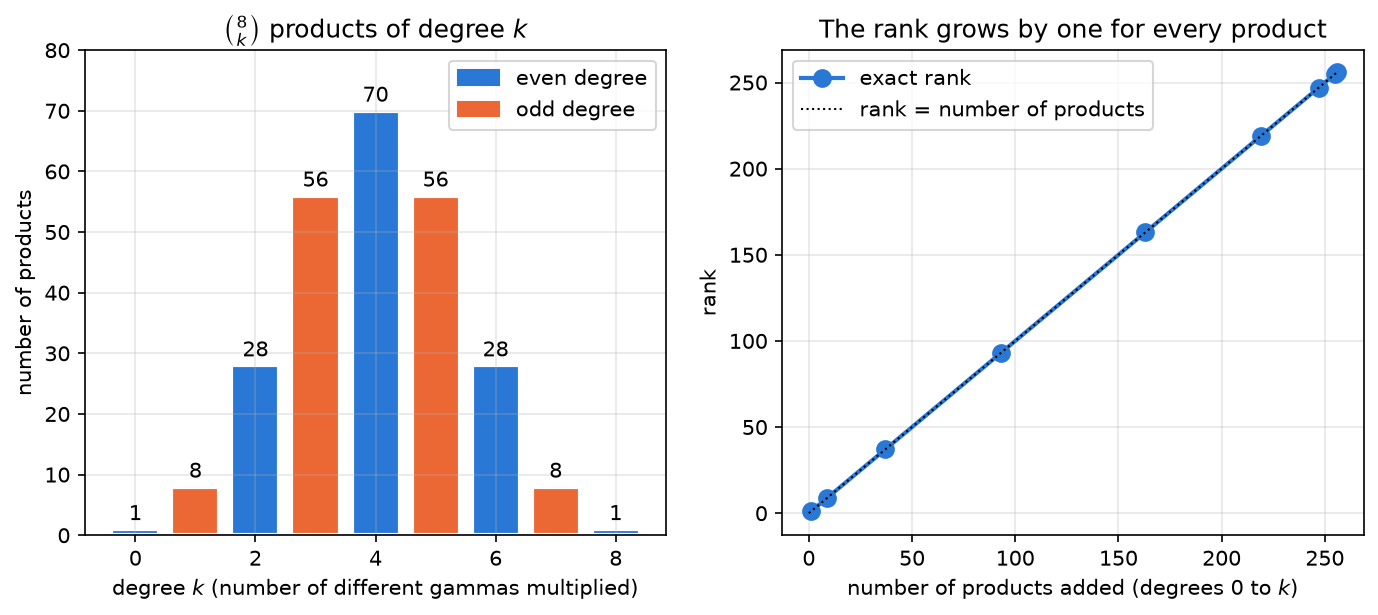

Figure 05b.1 saved as Revision/textbook/figures/05b_1_clifford_products.png


In [6]:
from matplotlib.patches import Patch  # a coloured square for a legend

degrees = np.arange(9)
counts = [len(products[k]) for k in range(9)]
colors = ["#2a78d6" if k % 2 == 0 else "#eb6834" for k in range(9)]
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.2))
axes[0].bar(degrees, counts, color=colors, edgecolor="white", linewidth=2)
for k in range(9):
    axes[0].text(k, counts[k] + 1.5, str(counts[k]), ha="center")
axes[0].set_xlabel("degree $k$ (number of different gammas multiplied)")
axes[0].set_ylabel("number of products")
axes[0].set_title(r"$\binom{8}{k}$ products of degree $k$")
axes[0].set_ylim(0, 80)
axes[0].legend(handles=[Patch(color="#2a78d6", label="even degree"),
                        Patch(color="#eb6834", label="odd degree")],
               loc="upper right")
added = np.cumsum(counts)  # how many products have been added up to degree k
axes[1].plot(added, cumulative, "o-", color="#2a78d6", linewidth=2, markersize=8,
             label="exact rank")
axes[1].plot([0, 256], [0, 256], ":", color="black", linewidth=1,
             label="rank = number of products")
axes[1].set_xlabel("number of products added (degrees 0 to $k$)")
axes[1].set_ylabel("rank")
axes[1].set_title("The rank grows by one for every product")
axes[1].legend(loc="upper left")
save_figure(fig, "clifford_products",
            "Left: the number of Clifford products of each degree $k$ (the number of "
            "different gammas multiplied), which is the binomial number "
            "$\\binom{8}{k}$: 1, 8, 28, 56, 70, 56, 28, 8, 1, in total 256; blue "
            "even degrees, orange odd degrees. Right: the exact rank of all "
            "products of degrees 0 to $k$ (dots) against the number of products "
            "added (horizontal axis); the dots lie on the dotted line rank = "
            "number of products, ending at 256: the 256 products are independent "
            "and span all 16 by 16 matrices.")

## 8. The commutant of the eight gammas: Pin(4,4) is irreducible

The next cell builds the $2048 \times 256$ system $X\gamma^a - \gamma^a X = 0$
($a = x1, \dots, x8$; with `commutation_system`, $L = R = \gamma^a$ gives
$\gamma^a X - X\gamma^a$, the same equations with the opposite sign), computes its
exact rank and a basis of its solutions, and checks that the only solutions are
the multiples of the identity.

In [7]:
gammas = [gamma[x] for x in COORDS]
A_pin = commutation_system(gammas, gammas)  # 8 x 256 = 2048 equations
rank_pin = exact_rank(A_pin)
basis_pin = solution_basis(A_pin, 16, 16)
dimension_pin = 256 - rank_pin
say(f"equations {A_pin.shape[0]}, unknowns {A_pin.shape[1]}, rank {rank_pin}, "
    f"dimension of the commutant {dimension_pin}")
only = basis_pin[0]
proportional = np.array_equal(only / only[0, 0], np.eye(16))  # a multiple of 1?
say(f"the basis solution divided by its entry (1,1) equals the identity: "
    f"{proportional}")
check_reproduces(dimension_pin == 1 and len(basis_pin) == 1 and proportional
                 and f"= {dimension_pin} (Fraction)"
                 in detail("python", "pin_commutant_dimension_1")
                 and recorded("python", "pin_commutant_dimension_1")
                 and recorded("wolfram", "Pin44_irreducible_commutant_dim_1"),
                 "only the multiples of 1 commute with all eight gammas: Pin(4,4) acts "
                 "irreducibly on the 16 components",
                 record=record_of("python", "pin_commutant_dimension_1"))

equations 2048, unknowns 256, rank 255, dimension of the commutant 1
the basis solution divided by its entry (1,1) equals the identity: True
PASS only the multiples of 1 commute with all eight gammas: Pin(4,4) acts irreducibly on
    the 16 components
     reproduces Revision/algebra/reports/python-algebra.json, check
    pin_commutant_dimension_1


**The second engine and what its eigenvalues mean.** The next cell computes the
eigenvalues of $N = A^T A$ ($256 \times 256$) with numpy and counts those below
$10^{-9}$: by section 4 their number is the dimension of the commutant. The
eigenvalues can even be predicted exactly. The equations for $\gamma^a$ act on $X$
as $X \to \gamma^a X - X\gamma^a$; the transposed equations act as $X \to
\eta_{aa}(\gamma^a X - X\gamma^a)$ (because $(\gamma^a)^T = \eta_{aa}\gamma^a$).
Take for $X$ a Clifford product $P$. If $\gamma^a$ commutes with $P$, the first
step gives 0. If it anticommutes, the first step gives $2\gamma^a P$, the second
$\eta_{aa}(2\gamma^a\gamma^a P - 2\gamma^a P\gamma^a) = \eta_{aa}(2\eta_{aa}P +
2\eta_{aa}P) = 4P$. So $NP = 4\, n(P)\, P$, where $n(P)$ is the number of gammas
that anticommute with $P$. By the sign rule for moving a gamma through $k$
different factors, $n(P) = k$ for even $k$ and $n(P) = 8 - k$ for odd $k$. The cell
checks $NP = 4n(P)P$ exactly for all 256 products and compares the predicted list
of eigenvalues with numpy's.

In [8]:
N_pin = A_pin.T @ A_pin  # 256 x 256, whole numbers, symmetric
eigen_pin = np.linalg.eigvalsh(N_pin.astype(float))  # sorted from small to large
zeros_pin = int(np.sum(np.abs(eigen_pin) < 1e-9))
say(f"numpy: eigenvalues of A^T A below 1e-9: {zeros_pin}")
predicted = []  # the eigenvalue 4 n(P) of every Clifford product P
exact_eigenvectors = True
for k in range(9):
    n_anti = k if k % 2 == 0 else 8 - k  # gammas anticommuting with a product
    for p in products[k]:
        predicted.append(4 * n_anti)
        exact_eigenvectors &= np.array_equal(N_pin @ p.reshape(256),
                                             4 * n_anti * p.reshape(256))
predicted = np.sort(np.array(predicted))
values, multiplicities = np.unique(predicted, return_counts=True)
say("predicted eigenvalues of A^T A, written value x multiplicity:")
say("    " + ", ".join(f"{v} x {c}" for v, c in zip(values, multiplicities)))
check(exact_eigenvectors and zeros_pin == 1
      and np.max(np.abs(eigen_pin - predicted)) < 1e-9,
      "A^T A has exactly one zero eigenvalue; every Clifford product P is an "
      "eigenvector with eigenvalue 4 n(P)")

numpy: eigenvalues of A^T A below 1e-9: 1
predicted eigenvalues of A^T A, written value x multiplicity:
    0 x 1, 4 x 8, 8 x 28, 12 x 56, 16 x 70, 20 x 56, 24 x 28, 28 x 8, 32 x 1
PASS A^T A has exactly one zero eigenvalue; every Clifford product P is an eigenvector
    with eigenvalue 4 n(P)


## 9. Imposing the gammas one at a time

How does the commutant shrink as more gammas are required to commute with $X$?
With no condition, all 256 entries are free. The matrices that commute with one
gamma, say $\gamma^{(x1)}$, are those that map each of its two eigenspaces
(eigenvalue $+1$ and $-1$, eight dimensions each) into itself: $8^2 + 8^2 = 128$
of them. The next cell computes the dimension after imposing $\gamma^{(x1)}$, then
also $\gamma^{(x2)}$, and so on up to all eight, exactly.

In [9]:
halving = [256]  # dimension of the commutant of the first j gammas, j = 0, 1, ..., 8
for j in range(1, 9):
    A_j = commutation_system(gammas[:j], gammas[:j])
    halving.append(256 - exact_rank(A_j))
for j in range(9):
    names = ", ".join(COORDS[:j]) if j else "none"
    say(f"gammas imposed: {j} ({names}); commutant dimension {halving[j]}")
check(halving == [256 // 2 ** j for j in range(9)],
      "every further gamma halves the commutant: 256, 128, 64, ..., 2, 1")

gammas imposed: 0 (none); commutant dimension 256
gammas imposed: 1 (x1); commutant dimension 128
gammas imposed: 2 (x1, x2); commutant dimension 64
gammas imposed: 3 (x1, x2, x3); commutant dimension 32
gammas imposed: 4 (x1, x2, x3, x4); commutant dimension 16
gammas imposed: 5 (x1, x2, x3, x4, x5); commutant dimension 8
gammas imposed: 6 (x1, x2, x3, x4, x5, x6); commutant dimension 4
gammas imposed: 7 (x1, x2, x3, x4, x5, x6, x7); commutant dimension 2
gammas imposed: 8 (x1, x2, x3, x4, x5, x6, x7, x8); commutant dimension 1
PASS every further gamma halves the commutant: 256, 128, 64, ..., 2, 1


## 10. The generators S^ab and the commutant of Spin(4,4)

The next cell builds the 28 generators $S^{ab} = \tfrac14[\gamma^a, \gamma^b]$
($a$ before $b$ in the order $x1, \dots, x8$). For $a \neq b$ the two gammas
anticommute, so $[\gamma^a, \gamma^b] = 2\gamma^a\gamma^b$ and $S^{ab} =
\tfrac12\gamma^a\gamma^b$: its entries are $0$ and $\pm\tfrac12$. It checks these
recorded facts and that every $S^{ab}$ is block diagonal. For the exact equation
system it uses the whole-number matrices $2S^{ab} = \gamma^a\gamma^b$, which have
the same commutant (a matrix commutes with $S$ exactly when it commutes with $2S$).

In [10]:
pairs = [(a, b) for i, a in enumerate(COORDS) for b in COORDS[i + 1:]]  # 28 pairs
S = {(a, b): (gamma[a] @ gamma[b] - gamma[b] @ gamma[a]) / 4 for a, b in pairs}
entries = sorted({float(v) for s in S.values() for v in s.flat})
say(f"{len(S)} generators S^ab; their entries are {entries}")
check_reproduces(len(S) == 28 and entries == [-0.5, 0.0, 0.5]
                 and all(np.array_equal(S[(a, b)], gamma[a] @ gamma[b] / 2)
                         for a, b in pairs)
                 and recorded("python", "S_definition"),
                 "S^ab = (1/4)[gamma^a, gamma^b] = (1/2) gamma^a gamma^b: 28 matrices "
                 "with entries 0, +1/2, -1/2",
                 record=record_of("python", "S_definition"))
check_reproduces(all(not s[:8, 8:].any() and not s[8:, :8].any() for s in S.values())
                 and recorded("python", "S_block_diagonal"),
                 "every S^ab is block diagonal: it maps each chiral half into itself",
                 record=record_of("python", "S_block_diagonal"))

28 generators S^ab; their entries are [-0.5, 0.0, 0.5]
PASS S^ab = (1/4)[gamma^a, gamma^b] = (1/2) gamma^a gamma^b: 28 matrices with entries 0,
    +1/2, -1/2
     reproduces Revision/algebra/reports/python-algebra.json, check S_definition
PASS every S^ab is block diagonal: it maps each chiral half into itself
     reproduces Revision/algebra/reports/python-algebra.json, check S_block_diagonal


The next cell solves $[X, 2S^{ab}] = 0$ for all 28 generators: $28 \times 256 =
7168$ equations for 256 unknowns. The solution space must have dimension 2 and be
spanned by $P_-$ and $P_+$: the cell checks that the two basis matrices that sympy
returns, together with $P_-$ and $P_+$, have rank 2 (they span the same space). The
second engine counts the zero eigenvalues of $A^T A$.

In [11]:
generators = [(gamma[a] @ gamma[b]).astype(np.int64) for a, b in pairs]  # 2 S^ab
A_spin = commutation_system(generators, generators)  # 7168 equations
rank_spin = exact_rank(A_spin)
basis_spin = solution_basis(A_spin, 16, 16)
dimension_spin = 256 - rank_spin
P_minus = np.diag([1] * 8 + [0] * 8)  # diag(1_8, 0): components 1 to 8
P_plus = np.diag([0] * 8 + [1] * 8)  # diag(0, 1_8): components 9 to 16
together = np.array([b.reshape(256) for b in basis_spin]
                    + [P_minus.reshape(256), P_plus.reshape(256)])
same_span = np.linalg.matrix_rank(together) == 2  # four matrices, two directions
eigen_spin = np.linalg.eigvalsh((A_spin.T @ A_spin).astype(float))
zeros_spin = int(np.sum(np.abs(eigen_spin) < 1e-9))
say(f"equations {A_spin.shape[0]}, rank {rank_spin}, dimension {dimension_spin}; "
    f"numpy: zero eigenvalues of A^T A: {zeros_spin}")
say(f"the basis and P_-, P_+ span the same space: {same_span}")
check_reproduces(dimension_spin == 2 and zeros_spin == 2 and same_span
                 and f"= {dimension_spin} (Fraction)"
                 in detail("python", "spin_commutant_dimension_2")
                 and recorded("python", "spin_commutant_dimension_2")
                 and recorded("wolfram", "Spin44_commutant_dim_2_chiral_projectors"),
                 "the commutant of the 28 S^ab has dimension 2, spanned by P_- and P_+",
                 record=record_of("python", "spin_commutant_dimension_2"))

equations 7168, rank 254, dimension 2; numpy: zero eigenvalues of A^T A: 2
the basis and P_-, P_+ span the same space: True
PASS the commutant of the 28 S^ab has dimension 2, spanned by P_- and P_+
     reproduces Revision/algebra/reports/python-algebra.json, check
    spin_commutant_dimension_2


The next cell draws the eigenvalues of $A^T A$ for both systems, sorted from the
smallest to the largest: for the eight gammas exactly one is zero (the levels 0,
4, 8, ..., 32 predicted above), for the 28 generators exactly two.

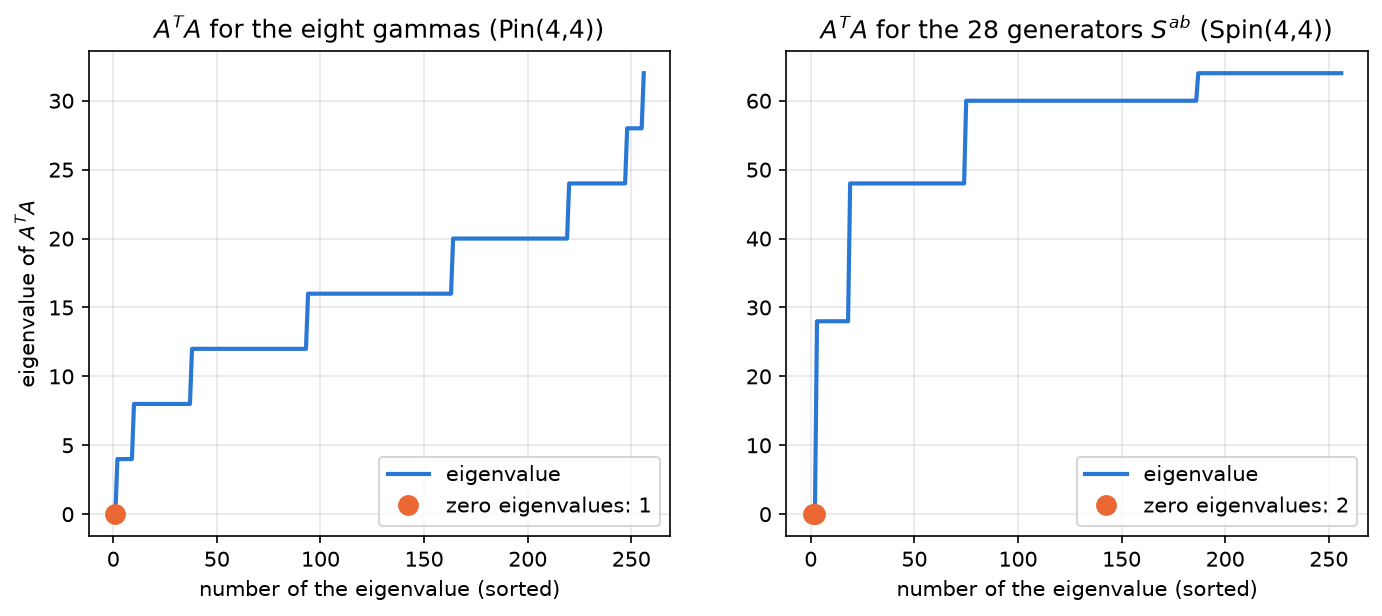

Figure 05b.2 saved as Revision/textbook/figures/05b_2_system_eigenvalues.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.2))
for ax, eig, zeros, title in [
        (axes[0], eigen_pin, zeros_pin, "eight gammas (Pin(4,4))"),
        (axes[1], eigen_spin, zeros_spin, "28 generators $S^{ab}$ (Spin(4,4))")]:
    index = np.arange(1, 257)  # the eigenvalues numbered 1 to 256
    ax.plot(index, eig, color="#2a78d6", linewidth=2, label="eigenvalue")
    ax.plot(index[:zeros], eig[:zeros], "o", color="#eb6834", markersize=9,
            label=f"zero eigenvalues: {zeros}")
    ax.set_xlabel("number of the eigenvalue (sorted)")
    ax.set_title(f"$A^T A$ for the {title}")
    ax.legend(loc="lower right")
axes[0].set_ylabel("eigenvalue of $A^T A$")
save_figure(fig, "system_eigenvalues",
            "The 256 eigenvalues of $A^T A$, sorted (horizontal axis: their number "
            "from 1 to 256; vertical axis: their value, a pure number), for the "
            "equation system of the commutant of the eight gammas (left) and of "
            "the 28 generators $S^{ab}$ (right). The number of zero eigenvalues "
            "(orange dots) is the dimension of the commutant: one on the left "
            "(only multiples of 1: Pin(4,4) is irreducible), two on the right "
            "(the projectors onto the two halves). On the left the eigenvalues "
            "come in the exact steps 0, 4, 8, ..., 32, four times the number of "
            "gammas that anticommute with a Clifford product.")

The next cell draws how the commutant shrinks when the gammas are imposed one at
a time (section 9). The vertical axis is logarithmic with base 2, so halving is a
step of equal size.

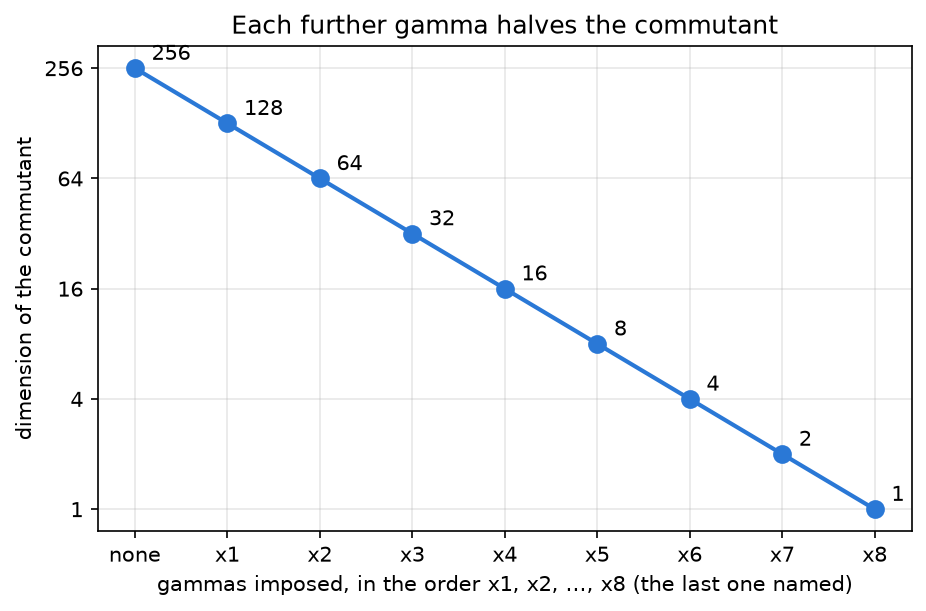

Figure 05b.3 saved as Revision/textbook/figures/05b_3_commutant_halving.png


In [13]:
fig, ax = plt.subplots(figsize=(7.0, 4.2))
ax.plot(range(9), halving, "o-", color="#2a78d6", linewidth=2, markersize=8)
for j in range(9):
    ax.annotate(str(halving[j]), (j, halving[j]), textcoords="offset points",
                xytext=(8, 4))
ax.set_yscale("log", base=2)
ax.set_yticks([1, 4, 16, 64, 256], ["1", "4", "16", "64", "256"])
ax.set_xticks(range(9), ["none"] + COORDS)
ax.set_xlabel("gammas imposed, in the order x1, x2, ..., x8 (the last one named)")
ax.set_ylabel("dimension of the commutant")
ax.set_title("Each further gamma halves the commutant")
save_figure(fig, "commutant_halving",
            "The dimension of the space of 16 by 16 matrices that commute with the "
            "gammas imposed so far (vertical axis, logarithmic with base 2), when the "
            "gammas are imposed one at a time in the order $x1$ to $x8$ (horizontal "
            "axis: the last gamma added). Without a condition all 256 entries are free; "
            "every further gamma halves the dimension, and with all eight only the "
            "multiples of the identity remain (dimension 1), computed exactly.")

The next cell draws the two basis matrices of the Spin(4,4) commutant as sympy
returned them, and $P_-$ and $P_+$. The basis matrices may look different from the
projectors (sympy picks its own basis); the check above showed that both pairs span
the same space: every matrix that commutes with all $S^{ab}$ is $pP_- + qP_+$, a
number $p$ on the first half and a number $q$ on the second.

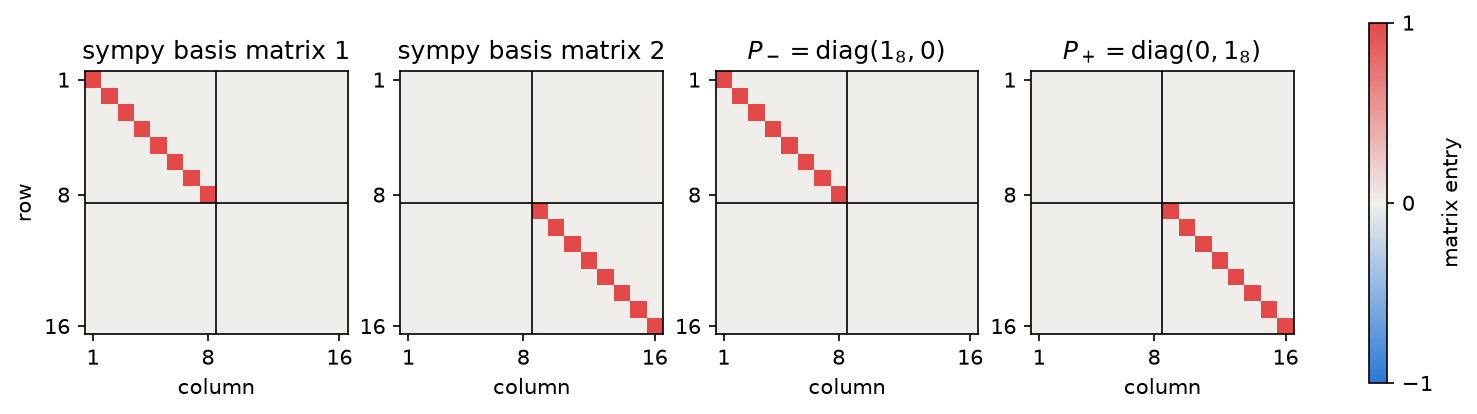

Figure 05b.4 saved as Revision/textbook/figures/05b_4_spin_commutant.png


In [14]:
from matplotlib.colors import LinearSegmentedColormap

SIGNS = LinearSegmentedColormap.from_list("signs", ["#2a78d6", "#f0efec", "#e34948"])
pictures = [(basis_spin[0], "sympy basis matrix 1"),
            (basis_spin[1], "sympy basis matrix 2"),
            (P_minus, "$P_- = \\mathrm{diag}(1_8, 0)$"),
            (P_plus, "$P_+ = \\mathrm{diag}(0, 1_8)$")]
fig, axes = plt.subplots(1, 4, figsize=(13.0, 3.9))
for k, (ax, (matrix, title)) in enumerate(zip(axes, pictures)):
    image = ax.imshow(matrix, cmap=SIGNS, vmin=-1, vmax=1)
    ax.set_title(title)
    ax.set_xticks([0, 7, 15], ["1", "8", "16"])
    ax.set_yticks([0, 7, 15], ["1", "8", "16"])
    ax.axhline(7.5, color="black", linewidth=0.8)
    ax.axvline(7.5, color="black", linewidth=0.8)
    ax.set_xlabel("column")
    if k == 0:
        ax.set_ylabel("row")
    ax.grid(False)
fig.colorbar(image, ax=axes, ticks=[-1, 0, 1], shrink=0.8, label="matrix entry")
save_figure(fig, "spin_commutant",
            "Heat maps of the two basis matrices of the commutant of the 28 generators "
            "$S^{ab}$ found by the exact solver (left two) and of the chiral projectors "
            "$P_-$ and $P_+$ (right two); horizontal axis the column, vertical axis the "
            "row (1 to 16); grey $0$, red $+1$ (no entry is negative). All four are "
            "diagonal and constant on each half (rows 1 to 8 and 9 to 16, separated by "
            "the black lines): every matrix that commutes with Spin(4,4) is a number "
            "times $P_-$ plus a number times $P_+$.")

## 11. The two halves: irreducible and inequivalent

Every $S^{ab}$ is $\mathrm{diag}(S_-^{ab}, S_+^{ab})$ with $8 \times 8$ blocks. The
next cell computes, exactly:

- the commutant of the 28 blocks $S_-^{ab}$ (64 unknowns): dimension 1 means the
  first half is irreducible; the same for the 28 blocks $S_+^{ab}$;
- the intertwiners $X$ with $X S_+^{ab} = S_-^{ab} X$ and with $X S_-^{ab} =
  S_+^{ab} X$ (with `commutation_system` the pairs are $(S_-, S_+)$ and $(S_+,
  S_-)$): dimension 0 means the only intertwiner is zero, so the halves are
  inequivalent;
- the **negative control**: the artificial $16 \times 16$ matrices
  $\mathrm{diag}(S_-^{ab}, S_-^{ab})$, two copies of the *same* half. Their
  commutant must have dimension 4 ($X = \begin{pmatrix} p 1_8 & q 1_8 \\ r 1_8 & s 1_8
  \end{pmatrix}$): this shows that the computation would detect equivalent halves.

In [15]:
minus_blocks = [g[:8, :8] for g in generators]  # the blocks of 2 S^ab on half -
plus_blocks = [g[8:, 8:] for g in generators]  # the blocks of 2 S^ab on half +
dim_minus = 64 - exact_rank(commutation_system(minus_blocks, minus_blocks))
dim_plus = 64 - exact_rank(commutation_system(plus_blocks, plus_blocks))
dim_minus_plus = 64 - exact_rank(commutation_system(minus_blocks, plus_blocks))
dim_plus_minus = 64 - exact_rank(commutation_system(plus_blocks, minus_blocks))
Z8 = np.zeros((8, 8), dtype=np.int64)
doubled = [np.block([[m, Z8], [Z8, m]]) for m in minus_blocks]  # the control
dim_control = 256 - exact_rank(commutation_system(doubled, doubled))
say(f"commutant on half -: {dim_minus}; on half +: {dim_plus}")
say(f"intertwiners: {dim_minus_plus} and {dim_plus_minus}")
say(f"control (two copies of half -): commutant dimension {dim_control}")
check_reproduces(dim_minus == 1 and dim_plus == 1
                 and "dimension 1 (sympy 1)"
                 in detail("python", "spin_halves_irreducible")
                 and recorded("python", "spin_halves_irreducible")
                 and recorded("wolfram", "chiral_halves_irreducible"),
                 "each chiral half is an irreducible representation of Spin(4,4)",
                 record=record_of("python", "spin_halves_irreducible"))
check_reproduces(dim_minus_plus == 0 and dim_plus_minus == 0
                 and "dimension 0 (sympy 0)"
                 in detail("python", "spin_halves_inequivalent")
                 and recorded("python", "spin_halves_inequivalent")
                 and recorded("wolfram", "chiral_halves_inequivalent_intertwiners_0"),
                 "the two halves are inequivalent: the only intertwiner is zero",
                 record=record_of("python", "spin_halves_inequivalent"))
check(dim_control == 4,
      "negative control: two copies of the same half give commutant dimension 4")

commutant on half -: 1; on half +: 1
intertwiners: 0 and 0
control (two copies of half -): commutant dimension 4
PASS each chiral half is an irreducible representation of Spin(4,4)
     reproduces Revision/algebra/reports/python-algebra.json, check
    spin_halves_irreducible
PASS the two halves are inequivalent: the only intertwiner is zero
     reproduces Revision/algebra/reports/python-algebra.json, check
    spin_halves_inequivalent
PASS negative control: two copies of the same half give commutant dimension 4


**Why Pin(4,4) sees one block of 16 and Spin(4,4) two blocks of 8.** The next
cell checks the recorded fact $\gamma^a P_- = P_+ \gamma^a$: every gamma (an odd
element of Pin(4,4), a *reflection*) carries the first half into the second and
back. So no half is invariant under Pin(4,4), while each half is invariant under
the even elements. Then it draws all the dimensions computed in this notebook.

PASS gamma^a P_- = P_+ gamma^a: every reflection exchanges the two halves
     reproduces Revision/algebra/reports/python-algebra.json, check
    reflections_exchange_halves


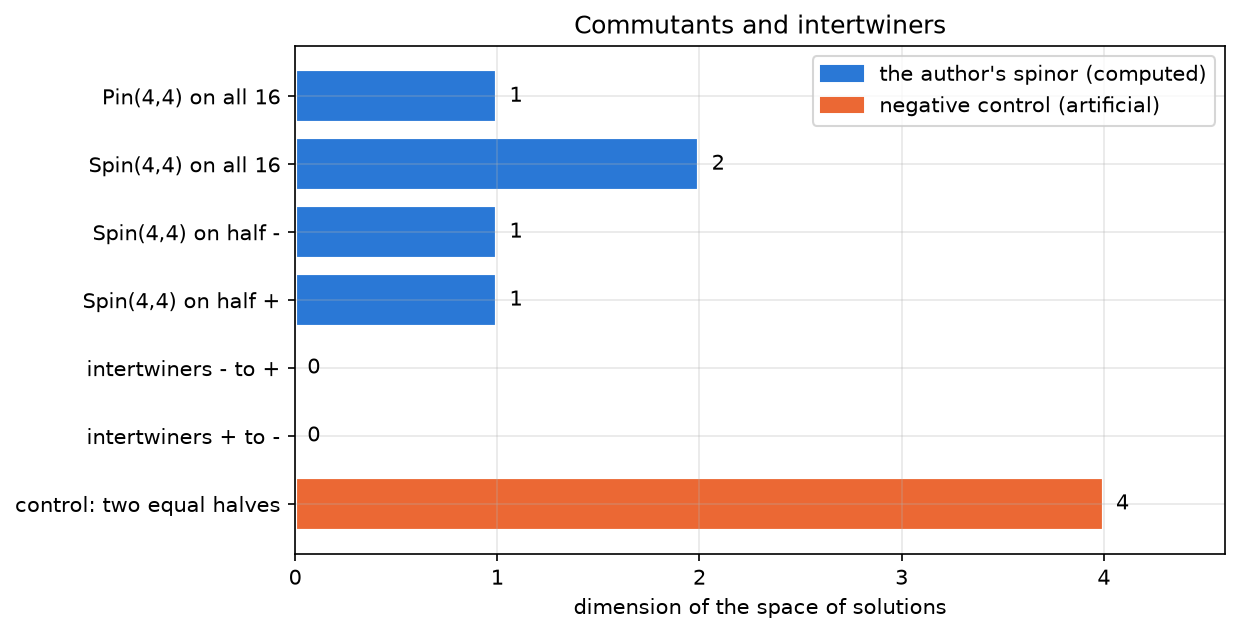

Figure 05b.5 saved as Revision/textbook/figures/05b_5_dimensions.png


In [16]:
check_reproduces(all(np.array_equal(gamma[x] @ P_minus, P_plus @ gamma[x])
                     for x in COORDS)
                 and recorded("python", "reflections_exchange_halves"),
                 "gamma^a P_- = P_+ gamma^a: every reflection exchanges the two halves",
                 record=record_of("python", "reflections_exchange_halves"))
labels = ["Pin(4,4) on all 16", "Spin(4,4) on all 16", "Spin(4,4) on half -",
          "Spin(4,4) on half +", "intertwiners - to +", "intertwiners + to -",
          "control: two equal halves"]
values = [dimension_pin, dimension_spin, dim_minus, dim_plus, dim_minus_plus,
          dim_plus_minus, dim_control]
colors = ["#2a78d6"] * 6 + ["#eb6834"]  # blue: the theory, orange: the control
fig, ax = plt.subplots(figsize=(8.0, 4.4))
positions = np.arange(len(labels))[::-1]  # the first label at the top
ax.barh(positions, values, color=colors, edgecolor="white", linewidth=2)
for y, v in zip(positions, values):
    ax.text(v + 0.06, y, str(v), va="center")
ax.set_yticks(positions, labels)
ax.set_xlim(0, 4.6)
ax.set_xlabel("dimension of the space of solutions")
ax.set_title("Commutants and intertwiners")
legend_squares = [Patch(color="#2a78d6", label="the author's spinor (computed)"),
                  Patch(color="#eb6834", label="negative control (artificial)")]
ax.legend(handles=legend_squares, loc="upper right")
save_figure(fig, "dimensions",
            "The dimensions computed exactly in this notebook (horizontal axis): the "
            "commutant of Pin(4,4) on the 16 components is 1 (irreducible); the "
            "commutant of Spin(4,4) is 2 (two invariant halves); the commutant on each "
            "half is 1 (each half irreducible); the intertwiners between the halves are "
            "0 in both directions (inequivalent halves). The orange bar is the negative "
            "control with two copies of the same half: equivalent halves give 4, so the "
            "value 2 above proves inequivalence.")

## 12. The last check

The last cell checks that the five figure files exist and prints the number of
checks that passed.

In [17]:
FIGURES = ["05b_1_clifford_products.png", "05b_2_system_eigenvalues.png",
           "05b_3_commutant_halving.png", "05b_4_spin_commutant.png",
           "05b_5_dimensions.png"]
check(all(output_file(f"{FIGURE_FOLDER}/{name}").is_file() for name in FIGURES),
      "the five figure files of notebook 05b exist")
all_checks_passed()

PASS the five figure files of notebook 05b exist
ALL 16 CHECKS PASSED (notebook 05b)


## 13. What this notebook showed

- A matrix equation $LX = XR$ for an unknown matrix is a system of linear
  equations; its solutions form a space of dimension (number of unknowns) minus
  (rank), and the rank can be computed exactly.
- The 256 Clifford products of the author's gammas are independent: they span all
  $16 \times 16$ matrices; the 128 even ones are block diagonal and span all
  block-diagonal matrices ($64 + 64$).
- Only the multiples of 1 commute with all eight gammas: the 16 components carry
  an **irreducible** representation of Pin(4,4). The equation system has exactly
  one zero eigenvalue of $A^T A$, and all its eigenvalues are predicted exactly by
  the sign rule. Each further gamma halves the commutant: 256, 128, ..., 1.
- The matrices that commute with the 28 generators $S^{ab}$ are exactly
  $pP_- + qP_+$ (dimension 2): under Spin(4,4) the components split into the two
  chiral halves of 8.
- Each half is irreducible, and the two halves are **inequivalent** (no nonzero
  intertwiner); the negative control with two equal halves gives 4 instead of 2.
  The gammas exchange the halves, which is how the two inequivalent halves of
  Spin(4,4) form one irreducible representation of Pin(4,4).
- Every one of these numbers equals the number recorded in
  `Revision/algebra/reports/python-algebra.json` and `wolfram-algebra.json`.